In [69]:
import warnings
warnings.filterwarnings("ignore")

In [70]:
import pandas as pd
import mysql.connector
# from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.frequent_patterns import fpgrowth, association_rules
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

# Database Connection
db_config = {"host": "localhost", "user": "root", "password": "", "database": "electrical_pos"}
conn = mysql.connector.connect(**db_config)

In [71]:
query = "SELECT ti.trans_id, p.product_name FROM transaction_items ti JOIN products p ON ti.product_id = p.product_id"
df = pd.read_sql(query, conn)
df.head() # Data ဝင်မဝင် စစ်ရန်

,trans_id,product_name
0,5,Inverter 1000W
1,10,Inverter 1000W
2,16,Inverter 1000W
3,18,Inverter 1000W
4,19,Inverter 1000W


In [72]:
basket = (df.groupby(['trans_id', 'product_name'])['product_name']
          .count().unstack().reset_index().fillna(0).set_index('trans_id'))
basket_sets = basket.applymap(lambda x: 1 if x >= 1 else 0)

# Mining
# apriori
# frequent_itemsets = apriori(basket_sets, min_support=0.05, use_colnames=True)
# fpgrwoth
frequent_itemsets = fpgrowth(basket_sets, min_support=0.05, use_colnames=True)


rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)


# Clean for visualization
rules['antecedents'] = rules['antecedents'].apply(lambda x: list(x)[0])
rules['consequents'] = rules['consequents'].apply(lambda x: list(x)[0])

rules.sort_values('lift', ascending=False).head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
51,Rice Cooker,Electric Kettle,0.136863,0.138861,0.132368,0.967153,6.964895,1.0,0.113363,26.216894,0.992221,0.923345,0.961857,0.960195
50,Electric Kettle,Rice Cooker,0.138861,0.136863,0.132368,0.953237,6.964895,1.0,0.113363,18.457850,0.994523,0.923345,0.945823,0.960195
108,Safety Goggles,Drill Machine,0.187812,0.193307,0.187812,1.000000,5.173127,1.0,0.151507,inf,0.993235,0.971576,1.000000,0.985788
113,Drill Machine,Safety Goggles,0.193307,0.187812,0.187812,0.971576,5.173127,1.0,0.151507,28.574244,1.000000,0.971576,0.965003,0.985788
110,Drill Machine,Safety Goggles,0.187812,0.194805,0.187812,1.000000,5.133333,1.0,0.151225,inf,0.991390,0.964103,1.000000,0.982051


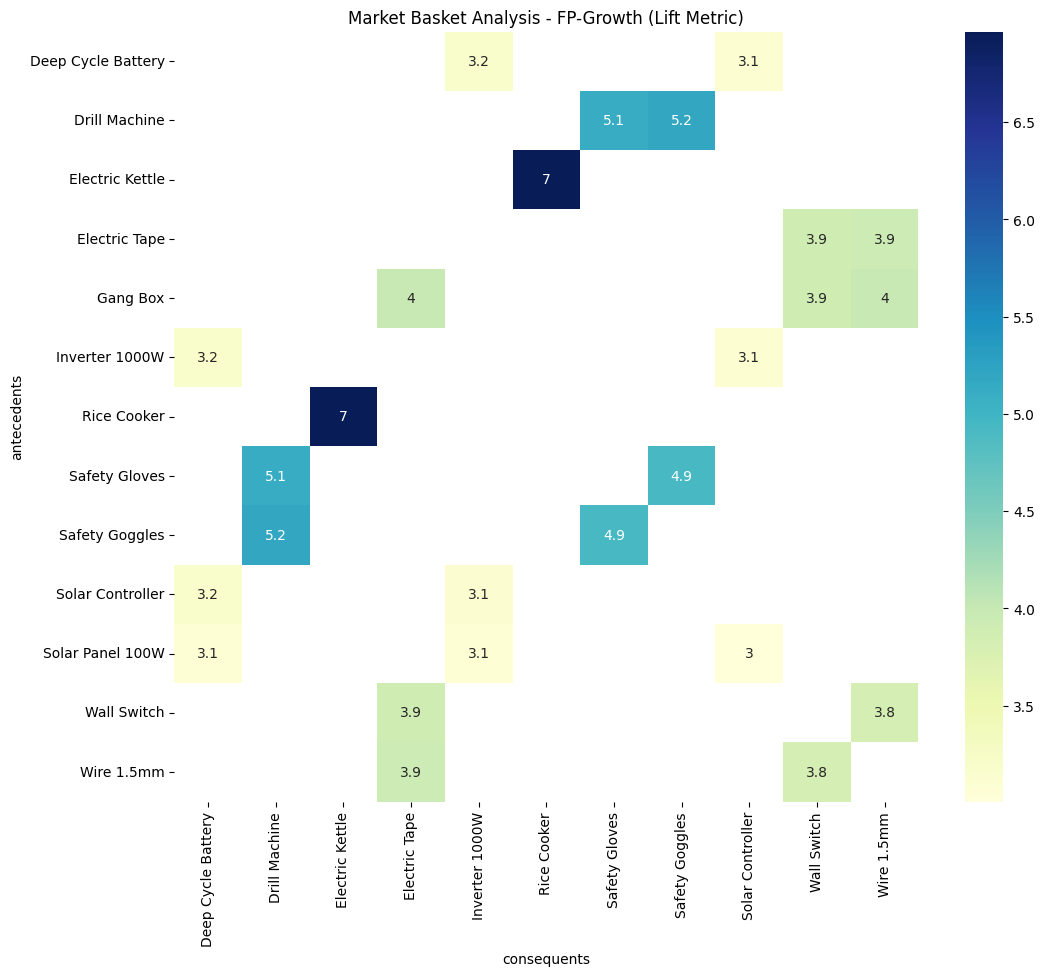

In [73]:
# pivot အစား pivot_table ကို သုံးပါမယ်
# aggfunc='max' က တကယ်လို့ rule တူတာရှိရင် အမြင့်ဆုံး lift value ကို ယူမယ်လို့ ပြောတာပါ
# pivot = rules.pivot_table(index='antecedents', columns='consequents', values='lift', aggfunc='max')

# plt.figure(figsize=(12, 10))
# sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5)
# plt.title('Product Association Strength (Lift Matrix)')
# plt.show()

# Confidence 0.5 ထက်များတဲ့ rule တွေကိုပဲ ယူမယ် (Heatmap ရှင်းအောင်လို့ပါ)
filtered_rules = rules[rules['confidence'] > 0.5]

# pivot_table ကို သုံးပြီး duplicate Index error ကို ရှင်းပါမယ်
pivot = filtered_rules.pivot_table(index='antecedents', columns='consequents', values='lift', aggfunc='max')

plt.figure(figsize=(12, 10))
sns.heatmap(pivot, annot=True, cmap="YlGnBu")
plt.title('Market Basket Analysis - FP-Growth (Lift Metric)')
plt.show()

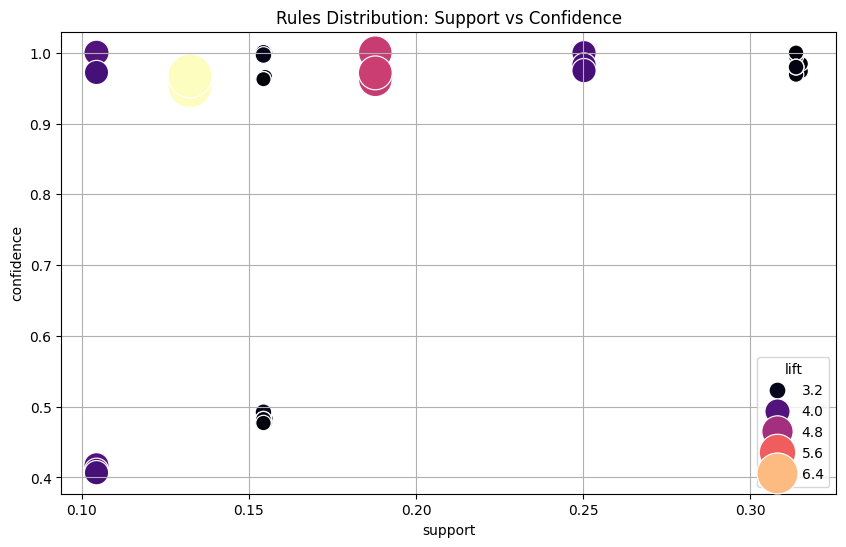

In [74]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="support", y="confidence", size="lift", hue="lift", 
                data=rules, palette="magma", sizes=(100, 1000))
plt.title('Rules Distribution: Support vs Confidence')
plt.grid(True)
plt.show()

In [75]:
# cursor = conn.cursor()
# cursor.execute("DROP TABLE IF EXISTS recommendation_rules")
# cursor.execute("""
#     CREATE TABLE recommendation_rules (
#         rule_id INT AUTO_INCREMENT PRIMARY KEY,
#         antecedent VARCHAR(255),
#         consequent VARCHAR(255),
#         confidence FLOAT,
#         lift FLOAT
#     )
# """)

# for idx, row in rules.iterrows():
#     cursor.execute("""
#         INSERT INTO recommendation_rules (antecedent, consequent, confidence, lift)
#         VALUES (%s, %s, %s, %s)
#     """, (row['antecedents'], row['consequents'], row['confidence'], row['lift']))

# conn.commit()
# conn.close()
# print("All rules saved to Database!")

# ၁။ အရင်ဆုံး Rule ထဲက Duplicate တွေကို ဖယ်ထုတ်ပြီး ရှင်းပစ်မယ်
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)).strip())
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(list(x)).strip())

# ပစ္စည်းအတွဲတူရင် Confidence အမြင့်ဆုံးတစ်ခုပဲ ယူမယ်
rules_cleaned = rules.sort_values('confidence', ascending=False).drop_duplicates(subset=['antecedents_str', 'consequents_str'])

# ၂။ Database ထဲ ထည့်မယ်
cursor = conn.cursor()
cursor.execute("TRUNCATE TABLE recommendation_rules") # အဟောင်းတွေကို အရင်ဖျက်ပါ

for idx, row in rules_cleaned.iterrows():
    # Antecedents ကို စစ်ဆေးပြီး String ပြောင်းခြင်း
    if isinstance(row['antecedents'], (set, frozenset)):
        ant = ", ".join(list(row['antecedents']))
    else:
        ant = str(row['antecedents'])

    # Consequents ကို စစ်ဆေးပြီး String ပြောင်းခြင်း
    if isinstance(row['consequents'], (set, frozenset)):
        con = ", ".join(list(row['consequents']))
    else:
        con = str(row['consequents'])
    
    # ပိုနေတဲ့ Space တွေကို ဖယ်ထုတ်မယ်
    ant = ant.strip()
    con = con.strip()

    cursor.execute("""
        INSERT INTO recommendation_rules (antecedent, consequent, confidence, lift)
        VALUES (%s, %s, %s, %s)
    """, (ant, con, row['confidence'], row['lift']))

conn.commit()
print("Fixed! All rules saved correctly.")

Fixed! All rules saved correctly.
